In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/SampleSuperstore_Cleaned.csv")

In [3]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub_category,product_name,sales,quantity,profit,payment_mode,returned,shipping_days
0,4918,CA-2019-160304,2019-01-01,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,Online,0.0,6
1,4919,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,Online,0.0,5
2,4920,CA-2019-160304,2019-01-02,2019-01-07,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,...,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,Cards,0.0,5
3,3074,CA-2019-125206,2019-01-03,2019-01-05,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,...,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,Online,0.0,2
4,8604,US-2019-116365,2019-01-03,2019-01-08,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,...,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,Online,0.0,5


In [4]:
df.shape

(5901, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row_id         5901 non-null   int64  
 1   order_id       5901 non-null   str    
 2   order_date     5901 non-null   str    
 3   ship_date      5901 non-null   str    
 4   ship_mode      5901 non-null   str    
 5   customer_id    5901 non-null   str    
 6   customer_name  5901 non-null   str    
 7   segment        5901 non-null   str    
 8   country        5901 non-null   str    
 9   city           5901 non-null   str    
 10  state          5901 non-null   str    
 11  region         5901 non-null   str    
 12  product_id     5901 non-null   str    
 13  category       5901 non-null   str    
 14  sub_category   5901 non-null   str    
 15  product_name   5901 non-null   str    
 16  sales          5901 non-null   float64
 17  quantity       5901 non-null   int64  
 18  profit         5901

In [6]:
total_sales = df["sales"].sum()
total_sales

np.float64(1565804.3232)

In [7]:
total_profit = df["profit"].sum()
total_profit

np.float64(175262.1059)

In [8]:
total_quantity = df["quantity"].sum()
total_quantity

np.int64(22317)

In [9]:
total_orders = df["order_id"].nunique()
total_orders

3003

In [10]:
return_rate = df["returned"].mean() * 100
return_rate

np.float64(4.863582443653618)

In [11]:
kpis = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Total Quantity": total_quantity,
    "Total Orders": total_orders,
    "Return Rate (%)": return_rate
}

kpis

{'Total Sales': np.float64(1565804.3232),
 'Total Profit': np.float64(175262.1059),
 'Total Quantity': np.int64(22317),
 'Total Orders': 3003,
 'Return Rate (%)': np.float64(4.863582443653618)}

Which product category generates the most sales?

In [13]:
sales_by_category = df.groupby("category")["sales"].sum().sort_values(ascending=False)

sales_by_category

category
Office Supplies    643707.6870
Technology         470587.9910
Furniture          451508.6452
Name: sales, dtype: float64

Profit by Category

In [15]:
profit_by_category = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_category

category
Technology         90458.2486
Office Supplies    74797.2461
Furniture          10006.6112
Name: profit, dtype: float64

calculate Profit Margin

In [16]:
category_analysis = pd.DataFrame({
    "Sales": sales_by_category,
    "Profit": profit_by_category
})

category_analysis["Profit_Margin_%"] = (
    category_analysis["Profit"] / category_analysis["Sales"]
) * 100

category_analysis

,Sales,Profit,Profit_Margin_%
category,,,
Furniture,451508.6452,10006.6112,2.216261
Office Supplies,643707.6870,74797.2461,11.619753
Technology,470587.9910,90458.2486,19.222388


EDA VISUALIZATION

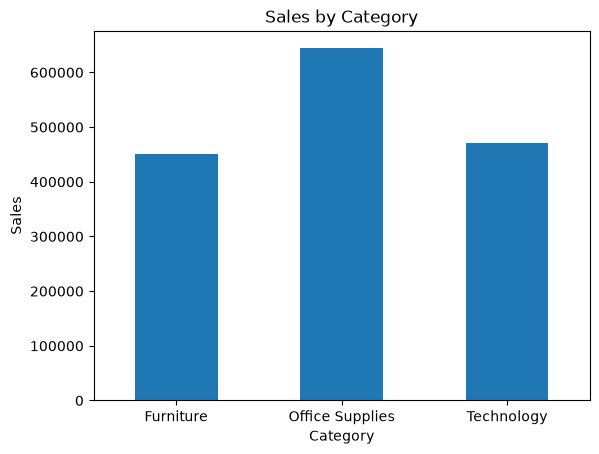

In [17]:
category_analysis["Sales"].plot(
    kind="bar",
    title="Sales by Category"
)

plt.ylabel("Sales")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

Profit by Category

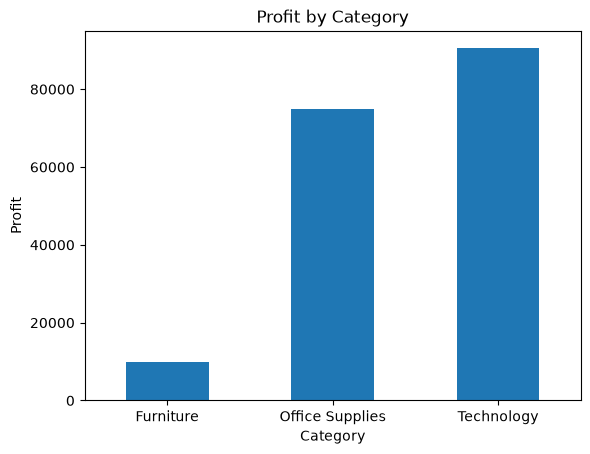

In [18]:
category_analysis["Profit"].plot(
    kind="bar",
    title="Profit by Category"
)

plt.ylabel("Profit")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.show()

Sales by Sub-Category

In [19]:
sales_by_subcategory = (
    df.groupby("sub_category")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_subcategory

sub_category
Phones         196563.5460
Chairs         181945.9980
Binders        174978.3900
Storage        150341.3180
Accessories    122301.0860
Tables         119293.7430
Paper           99453.6120
Furnishings     92691.2180
Machines        91987.5610
Appliances      80305.2470
Copiers         59735.7980
Bookcases       57577.6862
Art             50762.9760
Supplies        36720.9860
Labels          19397.4560
Envelopes       16542.4640
Fasteners       15205.2380
Name: sales, dtype: float64

Profit by Sub-Category

In [20]:
profit_by_subcategory = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_subcategory

sub_category
Copiers        42774.5828
Accessories    25336.6455
Phones         22308.9179
Paper          21112.3779
Binders        17885.3759
Storage        13607.0875
Chairs         13406.7032
Appliances     13166.6098
Furnishings     8034.4328
Art             3635.9257
Envelopes       3508.5073
Labels          2937.2212
Fasteners        598.4175
Machines          38.1024
Bookcases       -342.8883
Supplies       -1654.2767
Tables        -11091.6365
Name: profit, dtype: float64

In [21]:
subcategory_analysis = pd.DataFrame({
    "Sales": sales_by_subcategory,
    "Profit": profit_by_subcategory
})

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Profit"] /
    subcategory_analysis["Sales"]
) * 100

subcategory_analysis = subcategory_analysis.sort_values(
    "Profit",
    ascending=False
)

subcategory_analysis

,Sales,Profit,Profit_Margin_%
sub_category,,,
Copiers,59735.7980,42774.5828,71.606280
Accessories,122301.0860,25336.6455,20.716615
Phones,196563.5460,22308.9179,11.349469
Paper,99453.6120,21112.3779,21.228367
Binders,174978.3900,17885.3759,10.221477
Storage,150341.3180,13607.0875,9.050797
Chairs,181945.9980,13406.7032,7.368507
Appliances,80305.2470,13166.6098,16.395703
Furnishings,92691.2180,8034.4328,8.667955


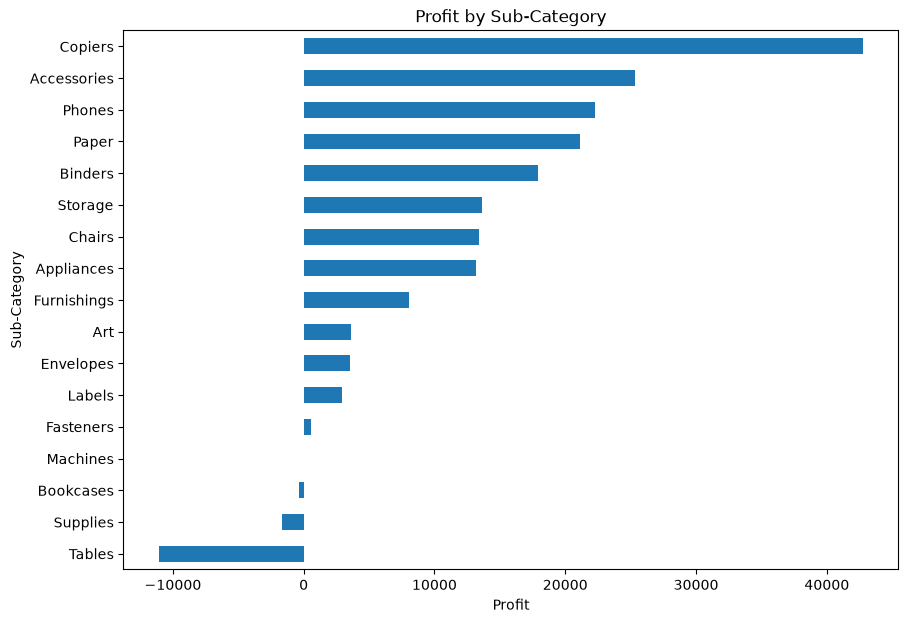

In [22]:
subcategory_analysis["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10, 7),
    title="Profit by Sub-Category"
)

plt.xlabel("Profit")
plt.ylabel("Sub-Category")
plt.show()

In [23]:
top_5_profit = subcategory_analysis.nlargest(5, "Profit")

top_5_profit

,Sales,Profit,Profit_Margin_%
sub_category,,,
Copiers,59735.798,42774.5828,71.606280
Accessories,122301.086,25336.6455,20.716615
Phones,196563.546,22308.9179,11.349469
Paper,99453.612,21112.3779,21.228367
Binders,174978.390,17885.3759,10.221477


In [24]:
bottom_5_profit = subcategory_analysis.nsmallest(5, "Profit")

bottom_5_profit

,Sales,Profit,Profit_Margin_%
sub_category,,,
Tables,119293.7430,-11091.6365,-9.297752
Supplies,36720.9860,-1654.2767,-4.504990
Bookcases,57577.6862,-342.8883,-0.595523
Machines,91987.5610,38.1024,0.041421
Fasteners,15205.2380,598.4175,3.935601


Which type of customer generates the most sales and profit?

In [26]:
sales_by_segment = (
    df.groupby("segment")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_segment

segment
Consumer       753002.1291
Corporate      509743.1262
Home Office    303059.0679
Name: sales, dtype: float64

Profit by Segment

In [27]:
profit_by_segment = (
    df.groupby("segment")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_segment

segment
Consumer       81338.5875
Corporate      57805.7991
Home Office    36117.7193
Name: profit, dtype: float64

Segment Profit Margin

In [28]:
segment_analysis = pd.DataFrame({
    "Sales": sales_by_segment,
    "Profit": profit_by_segment
})

segment_analysis["Profit_Margin_%"] = (
    segment_analysis["Profit"] / segment_analysis["Sales"]
) * 100

segment_analysis

,Sales,Profit,Profit_Margin_%
segment,,,
Consumer,753002.1291,81338.5875,10.801907
Corporate,509743.1262,57805.7991,11.340182
Home Office,303059.0679,36117.7193,11.917716


Visualize Segment Performance

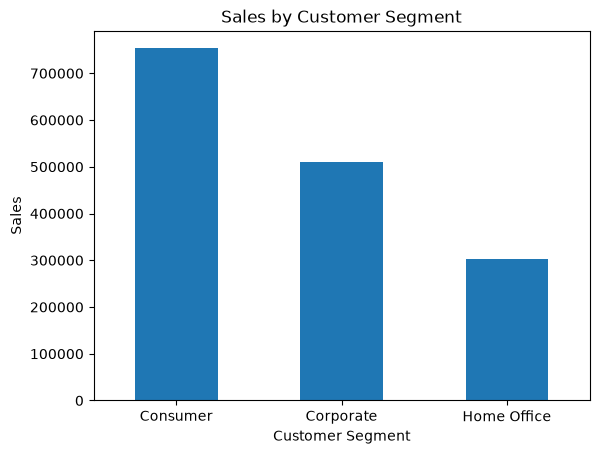

In [29]:
sales_by_segment.plot(
    kind="bar",
    title="Sales by Customer Segment"
)

plt.ylabel("Sales")
plt.xlabel("Customer Segment")
plt.xticks(rotation=0)
plt.show()

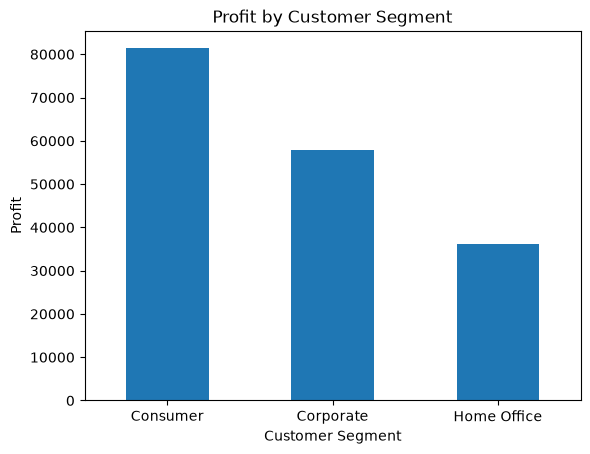

In [30]:
profit_by_segment.plot(
    kind="bar",
    title="Profit by Customer Segment"
)

plt.ylabel("Profit")
plt.xlabel("Customer Segment")
plt.xticks(rotation=0)
plt.show()

Sales by Region

In [31]:
sales_by_region = (
    df.groupby("region")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_region

region
West       522441.0520
East       450234.6660
Central    341007.5242
South      252121.0810
Name: sales, dtype: float64

# Profit by Region

In [32]:
profit_by_region = (
    df.groupby("region")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region

region
West       67859.9582
East       53400.4243
Central    27450.0071
South      26551.7163
Name: profit, dtype: float64

# Regional Profit Margin

In [36]:
region_analysis = pd.DataFrame({
    "Sales": sales_by_region,
    "Profit": profit_by_region
})

region_analysis["Profit_Margin_%"] = (
    region_analysis["Profit"] / region_analysis["Sales"]
) * 100

region_analysis

,Sales,Profit,Profit_Margin_%
region,,,
West,522441.0520,67859.9582,12.989017
East,450234.6660,53400.4243,11.860576
Central,341007.5242,27450.0071,8.049678
South,252121.0810,26551.7163,10.531335


# State-level analysis

In [37]:
sales_by_state = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_by_state.head(10)

state
California        335190.2560
New York          186748.0970
Texas             116261.9302
Washington         92975.1800
Pennsylvania       82354.9500
Ohio               68194.8600
Illinois           64224.3300
Florida            49914.9990
Michigan           48504.6840
North Carolina     39705.1250
Name: sales, dtype: float64

In [38]:
profit_by_state = (
    df.groupby("state")["profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_state.head(10)

state
California    49372.1750
New York      41012.0212
Washington    21466.6555
Michigan      17480.2806
Indiana       15524.6596
Georgia        9994.4165
Virginia       9657.4876
New Jersey     7213.0952
Delaware       7029.9107
Kentucky       5968.3840
Name: profit, dtype: float64

Bottom 10 states by profit

In [39]:
bottom_10_profit_states = (
    profit_by_state
    .sort_values(ascending=True)
    .head(10)
)

bottom_10_profit_states

state
Texas            -14078.1598
Illinois          -9554.6539
Ohio              -9339.4223
Pennsylvania      -9297.7975
Colorado          -5825.5857
North Carolina    -4827.6923
Tennessee         -3467.5906
Arizona           -2761.1100
Oregon             -942.9719
Florida            -227.7465
Name: profit, dtype: float64

Which sub-categories are causing Texas's losses?

In [40]:
texas_analysis = (
    df[df["state"] == "Texas"]
    .groupby("sub_category")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
    .sort_values("Profit")
)

texas_analysis

,Sales,Profit
sub_category,,
Binders,10609.6060,-7659.8194
Appliances,3791.8680,-3129.7449
Furnishings,6936.9440,-2509.6640
Bookcases,8906.2752,-1464.6408
Chairs,11503.2250,-1358.3217
Tables,8212.5580,-1232.3623
Supplies,5357.0560,-818.8526
Storage,12147.5920,-333.4219
Machines,2719.5340,-135.7782


Which specific products are causing the Binders losses?

In [41]:
texas_binders = (
    df[
        (df["state"] == "Texas") &
        (df["sub_category"] == "Binders")
    ]
    .groupby("product_name")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum")
    )
    .sort_values("Profit")
)

texas_binders

,Sales,Profit,Quantity
product_name,,,
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,1556.188,-2287.7820,6
GBC DocuBind P400 Electric Binding System,1088.792,-1850.9464,4
GBC Ibimaster 500 Manual ProClick Binding System,790.980,-1141.4700,5
Ibico Hi-Tech Manual Binding System,484.986,-747.2255,7
GBC ProClick 150 Presentation Binding System,290.784,-417.0936,4
...,...,...,...
Computer Printout Index Tabs,1.344,-2.1504,4
Avery Hidden Tab Dividers for Binding Systems,1.192,-2.0264,2
Zipper Ring Binder Pockets,102.248,-1.9344,2


# Time Analysis

In [46]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="mixed",
    dayfirst=True
)

In [47]:
df[["order_date", "ship_date"]].dtypes

order_date    datetime64[us]
ship_date     datetime64[us]
dtype: object

In [48]:
df["order_month"] = df["order_date"].dt.to_period("M").astype(str)

In [49]:
df[["order_date", "order_month"]].head()

,order_date,order_month
0,2019-01-01,2019-01
1,2019-02-01,2019-02
2,2019-02-01,2019-02
3,2019-03-01,2019-03
4,2019-03-01,2019-03


# Monthly Sales Trend

How does sales change month by month?

In [50]:
monthly_sales = (
    df.groupby("order_month")["sales"]
    .sum()
)

monthly_sales

order_month
2019-01     38122.1240
2019-02     25538.4100
2019-03     49612.0450
2019-04     45192.2780
2019-05     57964.3218
2019-06     38991.9430
2019-07     42773.3950
2019-08     45339.9884
2019-09     41985.1423
2019-10     52268.1500
2019-11     66837.5850
2019-12     60054.1555
2020-01     80812.3110
2020-02     74619.4894
2020-03     89024.0838
2020-04     50828.0016
2020-05     64210.4464
2020-06     62648.3255
2020-07     70684.0875
2020-08     90336.3040
2020-09    101880.6080
2020-10     79306.1622
2020-11    110574.2400
2020-12    126200.7258
Name: sales, dtype: float64

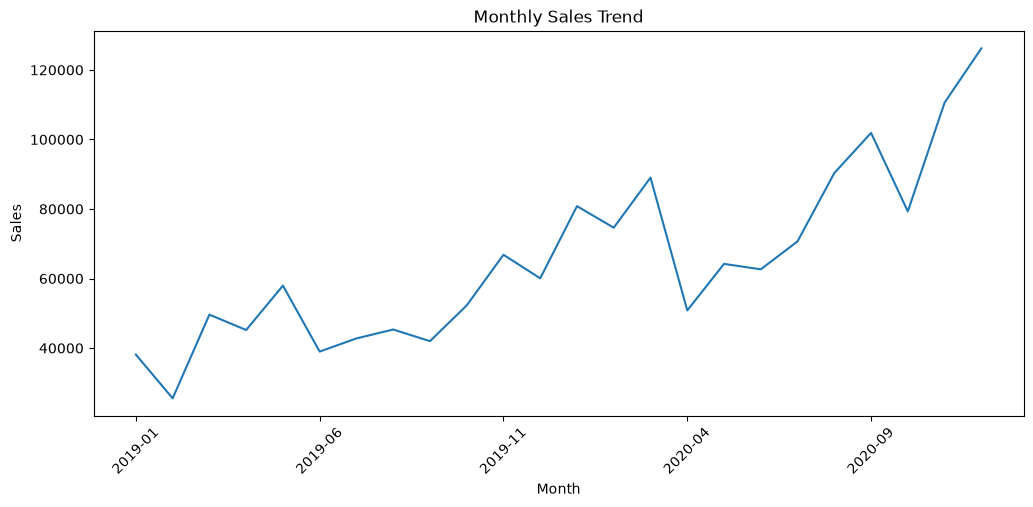

In [51]:
monthly_sales.plot(
    kind="line",
    figsize=(12, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

# Monthly Profit

In [52]:
monthly_profit = (
    df.groupby("order_month")["profit"]
    .sum()
)

monthly_profit

order_month
2019-01     8529.4358
2019-02    14683.7152
2019-03     1950.3496
2019-04     7423.2803
2019-05     9975.3694
2019-06     4480.3350
2019-07     6122.4545
2019-08      859.4491
2019-09     5171.8973
2019-10     8256.4675
2019-11     3057.5166
2019-12    11313.1708
2020-01    10879.4151
2020-02     4243.9720
2020-03    18127.8605
2020-04    -5890.0374
2020-05     7567.3914
2020-06     7396.3759
2020-07     4997.9408
2020-08    11767.3512
2020-09     9221.4166
2020-10     6572.0675
2020-11    11141.8845
2020-12     7413.0267
Name: profit, dtype: float64

April 2020 by category

In [53]:
april_2020_analysis = (
    df[df["order_month"] == "2020-04"]
    .groupby("category")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
    .sort_values("Profit")
)

april_2020_analysis

,Sales,Profit
category,,
Technology,14084.4330,-6985.2427
Furniture,14177.1636,-116.2677
Office Supplies,22566.4050,1211.4730


In [54]:
april_tech_analysis = (
    df[
        (df["order_month"] == "2020-04") &
        (df["category"] == "Technology")
    ]
    .groupby("sub_category")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
    .sort_values("Profit")
)

april_tech_analysis

,Sales,Profit
sub_category,,
Machines,6254.965,-7512.5504
Phones,5153.594,178.3065
Accessories,2675.874,349.0012


In [55]:
april_machines = (
    df[
        (df["order_month"] == "2020-04") &
        (df["category"] == "Technology") &
        (df["sub_category"] == "Machines")
    ]
    .groupby("product_name")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum")
    )
    .sort_values("Profit")
)

april_machines

,Sales,Profit,Quantity
product_name,,,
Cubify CubeX 3D Printer Triple Head Print,3009.980,-3839.9904,4
Lexmark MX611dhe Monochrome Laser Printer,2579.985,-3399.9800,5
Okidata C610n Printer,665.000,-272.5800,2


In [56]:
returns_by_category = (
    df.groupby("category")["returned"]
    .sum()
    .sort_values(ascending=False)
)

returns_by_category

category
Office Supplies    165.0
Furniture           70.0
Technology          52.0
Name: returned, dtype: float64

In [57]:
return_rate_by_category = (
    df.groupby("category")
    .agg(
        Total_Orders=("order_id", "count"),
        Returned_Orders=("returned", "sum")
    )
)

return_rate_by_category["Return_Rate_%"] = (
    return_rate_by_category["Returned_Orders"]
    / return_rate_by_category["Total_Orders"]
) * 100

return_rate_by_category.sort_values(
    "Return_Rate_%",
    ascending=False
)

,Total_Orders,Returned_Orders,Return_Rate_%
category,,,
Furniture,1249,70.0,5.604484
Technology,1083,52.0,4.801477
Office Supplies,3569,165.0,4.623144


# Return Rate by Sub-Category

In [58]:
return_rate_by_subcategory = (
    df.groupby("sub_category")
    .agg(
        Total_Orders=("order_id", "count"),
        Returned_Orders=("returned", "sum")
    )
)

return_rate_by_subcategory["Return_Rate_%"] = (
    return_rate_by_subcategory["Returned_Orders"]
    / return_rate_by_subcategory["Total_Orders"]
) * 100

return_rate_by_subcategory.sort_values(
    "Return_Rate_%",
    ascending=False
).head(10)

,Total_Orders,Returned_Orders,Return_Rate_%
sub_category,,,
Appliances,279,18.0,6.451613
Tables,190,12.0,6.315789
Phones,519,29.0,5.587669
Furnishings,573,32.0,5.584642
Chairs,355,19.0,5.352113
Bookcases,131,7.0,5.343511
Envelopes,133,7.0,5.263158
Copiers,38,2.0,5.263158
Binders,915,46.0,5.027322


# Feature Engineering & Business Insight Preparation.

In [59]:
df.columns.tolist()

['row_id',
 'order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'segment',
 'country',
 'city',
 'state',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'profit',
 'payment_mode',
 'returned',
 'shipping_days',
 'order_month']

In [60]:
df["order_year"] = df["order_date"].dt.year

In [61]:
df[["order_date", "order_month", "order_year"]].head()

,order_date,order_month,order_year
0,2019-01-01,2019-01,2019
1,2019-02-01,2019-02,2019
2,2019-02-01,2019-02,2019
3,2019-03-01,2019-03,2019
4,2019-03-01,2019-03,2019


# profit_margin

Profit Margin % = (Profit ÷ Sales) × 100

In [62]:
df["profit_margin"] = (
    df["profit"] / df["sales"]
) * 100

In [63]:
df[["sales", "profit", "profit_margin"]].head()

,sales,profit,profit_margin
0,73.94,28.2668,38.229375
1,173.94,38.2668,22.000000
2,231.98,67.2742,29.000000
3,114.46,28.6150,25.000000
4,30.08,-5.2640,-17.500000


In [64]:
df["profit_margin"].describe()

count    5901.000000
mean       10.060998
std        46.625926
min      -537.284079
25%         1.802112
50%         9.746524
75%        29.000000
max      1680.163216
Name: profit_margin, dtype: float64

In [65]:
df["profit_margin"].isna().sum()

np.int64(0)

# sales_per_quantity

In [66]:
df["sales_per_quantity"] = df["sales"] / df["quantity"]

In [67]:
df[["sales", "quantity", "sales_per_quantity"]].head()

,sales,quantity,sales_per_quantity
0,73.94,1,73.94
1,173.94,3,57.98
2,231.98,2,115.99
3,114.46,2,57.23
4,30.08,2,15.04


# profit_per_quantity

In [68]:
df["profit_per_quantity"] = df["profit"] / df["quantity"]

In [69]:
df[["profit", "quantity", "profit_per_quantity"]].head()

,profit,quantity,profit_per_quantity
0,28.2668,1,28.2668
1,38.2668,3,12.7556
2,67.2742,2,33.6371
3,28.6150,2,14.3075
4,-5.2640,2,-2.6320


# is_profitable

In [70]:
df["is_profitable"] = df["profit"] > 0

In [71]:
df[["profit", "is_profitable"]].head(10)

,profit,is_profitable
0,28.2668,True
1,38.2668,True
2,67.2742,True
3,28.6150,True
4,-5.2640,False
5,-6.2100,False
6,13.5720,True
7,350.4270,True
8,5.3460,True
9,119.9960,True


# Profitable vs Loss-Making Orders

In [72]:
profitability_summary = df["is_profitable"].value_counts()

profitability_summary

is_profitable
True     4764
False    1137
Name: count, dtype: int64

In [73]:
profitability_percentage = (
    df["is_profitable"]
    .value_counts(normalize=True)
    .mul(100)
)

profitability_percentage

is_profitable
True     80.732079
False    19.267921
Name: proportion, dtype: float64

# order_quarter

In [74]:
df["order_quarter"] = df["order_date"].dt.quarter

In [75]:
df[["order_date", "order_year", "order_quarter"]].head(10)

,order_date,order_year,order_quarter
0,2019-01-01,2019,1
1,2019-02-01,2019,1
2,2019-02-01,2019,1
3,2019-03-01,2019,1
4,2019-03-01,2019,1
5,2019-03-01,2019,1
6,2019-03-01,2019,1
7,2019-03-01,2019,1
8,2019-03-01,2019,1
9,2019-04-01,2019,2


In [76]:
df[
    [
        "order_year",
        "order_month",
        "order_quarter",
        "shipping_days",
        "profit_margin",
        "sales_per_quantity",
        "profit_per_quantity",
        "is_profitable"
    ]
].head()

,order_year,order_month,order_quarter,shipping_days,profit_margin,sales_per_quantity,profit_per_quantity,is_profitable
0,2019,2019-01,1,6,38.229375,73.94,28.2668,True
1,2019,2019-02,1,5,22.000000,57.98,12.7556,True
2,2019,2019-02,1,5,29.000000,115.99,33.6371,True
3,2019,2019-03,1,2,25.000000,57.23,14.3075,True
4,2019,2019-03,1,5,-17.500000,15.04,-2.6320,False


In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   row_id               5901 non-null   int64         
 1   order_id             5901 non-null   str           
 2   order_date           5901 non-null   datetime64[us]
 3   ship_date            5901 non-null   datetime64[us]
 4   ship_mode            5901 non-null   str           
 5   customer_id          5901 non-null   str           
 6   customer_name        5901 non-null   str           
 7   segment              5901 non-null   str           
 8   country              5901 non-null   str           
 9   city                 5901 non-null   str           
 10  state                5901 non-null   str           
 11  region               5901 non-null   str           
 12  product_id           5901 non-null   str           
 13  category             5901 non-null   str    

# Business Insight Generation 

Yearly Business Performance

In [78]:
yearly_summary = (
    df.groupby("order_year")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum"),
        Orders=("order_id", "nunique"),
        Avg_Profit_Margin=("profit_margin", "mean")
    )
)

yearly_summary

,Sales,Profit,Quantity,Orders,Avg_Profit_Margin
order_year,,,,,
2019,5.646795e+05,81823.4411,9838,1315,14.296518
2020,1.001125e+06,93438.6648,12479,1688,6.752357


Calculate Year-over-Year Growth

In [79]:
yoy_growth = (
    yearly_summary[
        ["Sales", "Profit", "Quantity", "Orders"]
    ]
    .pct_change() * 100
)

yoy_growth

,Sales,Profit,Quantity,Orders
order_year,,,,
2019,NaN,NaN,NaN,NaN
2020,77.290785,14.195472,26.844887,28.365019


calculate the actual overall profit margin

In [80]:
overall_margin_by_year = (
    yearly_summary["Profit"]
    / yearly_summary["Sales"]
) * 100

overall_margin_by_year

order_year
2019    14.490244
2020     9.333368
dtype: float64

identify what caused the margin decline

In [81]:
category_yearly = (
    df.groupby(["order_year", "category"])
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
)

category_yearly["Profit_Margin_%"] = (
    category_yearly["Profit"]
    / category_yearly["Sales"]
) * 100

category_yearly

Sales      Profit  Profit_Margin_%
order_year category                                                 
2019       Furniture        195275.3760   6988.2199         3.578649
           Office Supplies  174939.9820  35061.2292        20.041862
           Technology       194464.1800  39773.9920        20.453120
2020       Furniture        256233.2692   3018.3913         1.177986
           Office Supplies  468767.7050  39736.0169         8.476697
           Technology       276123.8110  50684.2566        18.355627

In [82]:
category_margin_change = (
    category_yearly["Profit_Margin_%"]
    .unstack()
    .T
)

category_margin_change["Margin_Change_pp"] = (
    category_margin_change[2020]
    - category_margin_change[2019]
)

category_margin_change.sort_values(
    "Margin_Change_pp"
)

order_year,2019,2020,Margin_Change_pp
category,,,
Office Supplies,20.041862,8.476697,-11.565165
Furniture,3.578649,1.177986,-2.400663
Technology,20.453120,18.355627,-2.097493


find the cause inside Office Supplies

In [83]:
office_subcategory_yearly = (
    df[
        df["category"] == "Office Supplies"
    ]
    .groupby(["order_year", "sub_category"])
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
)

office_subcategory_yearly["Profit_Margin_%"] = (
    office_subcategory_yearly["Profit"]
    / office_subcategory_yearly["Sales"]
) * 100

office_subcategory_yearly

Sales      Profit  Profit_Margin_%
order_year sub_category                                         
2019       Appliances     25050.315   5301.3415        21.162774
           Art             5960.908   1413.9626        23.720591
           Binders        42683.325  10215.6341        23.933548
           Envelopes       4729.890   2066.7483        43.695483
           Fasteners        960.134    294.0734        30.628371
           Labels          2827.240   1192.6119        42.182903
           Paper          21661.894   9071.5345        41.877845
           Storage        56788.700   6204.2868        10.925214
           Supplies       14277.576   -698.9639        -4.895536
2020       Appliances     55254.932   7865.2683        14.234509
           Art            44802.068   2221.9631         4.959510
           Binders       132295.065   7669.7418         5.797451
           Envelopes      11812.574   1441.7590        12.205291
           Fasteners      14245.104    304.3441         2.136482
           Labels         16570.216   1744.6093        10.528585
           Paper          77791.718  12040.8434        15.478310
           Storage        93552.618   7402.8007         7.912981
           Supplies       22443.410   -955.3128        -4.256540

In [85]:
office_margin_change = (
    office_subcategory_yearly["Profit_Margin_%"]
    .unstack()
)

office_margin_change

sub_category,Appliances,Art,Binders,Envelopes,Fasteners,Labels,Paper,Storage,Supplies
order_year,,,,,,,,,
2019,21.162774,23.720591,23.933548,43.695483,30.628371,42.182903,41.877845,10.925214,-4.895536
2020,14.234509,4.959510,5.797451,12.205291,2.136482,10.528585,15.478310,7.912981,-4.256540


In [86]:
office_margin_change = office_margin_change.T

office_margin_change

order_year,2019,2020
sub_category,,
Appliances,21.162774,14.234509
Art,23.720591,4.959510
Binders,23.933548,5.797451
Envelopes,43.695483,12.205291
Fasteners,30.628371,2.136482
Labels,42.182903,10.528585
Paper,41.877845,15.478310
Storage,10.925214,7.912981
Supplies,-4.895536,-4.256540


In [87]:
office_margin_change["Margin_Change_pp"] = (
    office_margin_change[2020]
    - office_margin_change[2019]
)

office_margin_change.sort_values(
    "Margin_Change_pp"
)

order_year,2019,2020,Margin_Change_pp
sub_category,,,
Labels,42.182903,10.528585,-31.654318
Envelopes,43.695483,12.205291,-31.490193
Fasteners,30.628371,2.136482,-28.491889
Paper,41.877845,15.478310,-26.399535
Art,23.720591,4.959510,-18.761081
Binders,23.933548,5.797451,-18.136097
Appliances,21.162774,14.234509,-6.928265
Storage,10.925214,7.912981,-3.012233
Supplies,-4.895536,-4.256540,0.638996


Find the actual profit impact

In [88]:
office_profit_impact = (
    df[df["category"] == "Office Supplies"]
    .groupby(["order_year", "sub_category"])
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum")
    )
)

office_profit_impact

Sales      Profit
order_year sub_category                        
2019       Appliances     25050.315   5301.3415
           Art             5960.908   1413.9626
           Binders        42683.325  10215.6341
           Envelopes       4729.890   2066.7483
           Fasteners        960.134    294.0734
           Labels          2827.240   1192.6119
           Paper          21661.894   9071.5345
           Storage        56788.700   6204.2868
           Supplies       14277.576   -698.9639
2020       Appliances     55254.932   7865.2683
           Art            44802.068   2221.9631
           Binders       132295.065   7669.7418
           Envelopes      11812.574   1441.7590
           Fasteners      14245.104    304.3441
           Labels         16570.216   1744.6093
           Paper          77791.718  12040.8434
           Storage        93552.618   7402.8007
           Supplies       22443.410   -955.3128

In [89]:
binders_yearly = (
    df[
        (df["category"] == "Office Supplies") &
        (df["sub_category"] == "Binders")
    ]
    .groupby("order_year")
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum"),
        Orders=("order_id", "nunique")
    )
)

binders_yearly["Profit_Margin_%"] = (
    binders_yearly["Profit"]
    / binders_yearly["Sales"]
) * 100

binders_yearly

,Sales,Profit,Quantity,Orders,Profit_Margin_%
order_year,,,,,
2019,42683.325,10215.6341,1603,353,23.933548
2020,132295.065,7669.7418,2067,432,5.797451


In [90]:
binders_products = (
    df[
        (df["category"] == "Office Supplies") &
        (df["sub_category"] == "Binders")
    ]
    .groupby(["order_year", "product_name"])
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum")
    )
)

binders_products

Sales  \
order_year product_name                                                  
2019       3-ring staple pack                                   10.528   
           ACCOHIDE 3-Ring Binder, Blue, 1"                     42.952   
           ACCOHIDE Binder by Acco                               7.434   
           Acco 3-Hole Punch                                     2.628   
           Acco Data Flex Cable Posts For Top & Bottom Loa...   66.752   
...                                                                ...   
2020       Wilson Jones data.warehouse D-Ring Binders with...  109.938   
           Wilson Jones “Snap” Scratch Pad Binder Tool for...  232.720   
           XtraLife ClearVue Slant-D Ring Binder, White, 3"    273.824   
           XtraLife ClearVue Slant-D Ring Binders by Cardinal  107.760   
           Zipper Ring Binder Pockets                          548.256   

                                                                Profit  \
order_year product_name                                                  
2019       3-ring staple pack                                   3.6848   
           ACCOHIDE 3-Ring Binder, Blue, 1"                    16.6852   
           ACCOHIDE Binder by Acco                             -5.6994   
           Acco 3-Hole Punch                                   -1.9272   
           Acco Data Flex Cable Posts For Top & Bottom Loa...  20.8600   
...                                                                ...   
2020       Wilson Jones data.warehouse D-Ring Binders with...  -3.6212   
           Wilson Jones “Snap” Scratch Pad Binder Tool for...  -5.8000   
           XtraLife ClearVue Slant-D Ring Binder, White, 3"    36.4064   
           XtraLife ClearVue Slant-D Ring Binders by Cardinal  -7.8400   
           Zipper Ring Binder Pockets                           8.2056   

                                                               Quantity  
order_year product_name                                                  
2019       3-ring staple pack                                         7  
           ACCOHIDE 3-Ring Binder, Blue, 1"                          12  
           ACCOHIDE Binder by Acco                                    6  
           Acco 3-Hole Punch                                          2  
           Acco Data Flex Cable Posts For Top & Bottom Loa...         8  
...                                                                 ...  
2020       Wilson Jones data.warehouse D-Ring Binders with...         2  
           Wilson Jones “Snap” Scratch Pad Binder Tool for...         8  
           XtraLife ClearVue Slant-D Ring Binder, White, 3"           8  
           XtraLife ClearVue Slant-D Ring Binders by Cardinal         5  
           Zipper Ring Binder Pockets                                17  

[374 rows x 3 columns]

In [93]:
binder_profit_change.tail(10)

product_name,3-ring staple pack,3M Organizer Strips,"ACCOHIDE 3-Ring Binder, Blue, 1""",ACCOHIDE Binder by Acco,Acco 3-Hole Punch,Acco D-Ring Binder w/DublLock,"Acco Data Flex Cable Posts For Top & Bottom Load Binders, 6"" Capacity",Acco Economy Flexible Poly Round Ring Binder,Acco Expandable Hanging Binders,"Acco Flexible ACCOHIDE Square Ring Data Binder, Dark Blue, 11 1/2"" X 14"" 7/8""",...,"Wilson Jones Ledger-Size, Piano-Hinge Binder, 2"", Blue",Wilson Jones Legal Size Ring Binders,Wilson Jones Standard D-Ring Binders,Wilson Jones Suede Grain Vinyl Binders,Wilson Jones Turn Tabs Binder Tool for Ring Binders,Wilson Jones data.warehouse D-Ring Binders with DublLock,Wilson Jones “Snap” Scratch Pad Binder Tool for Ring Binders,"XtraLife ClearVue Slant-D Ring Binder, White, 3""",XtraLife ClearVue Slant-D Ring Binders by Cardinal,Zipper Ring Binder Pockets
order_year,,,,,,,,,,,,,,,,,,,,,
2019,3.6848,NaN,16.6852,-5.6994,-1.9272,NaN,20.860,1.305,5.8696,31.8892,...,-49.9956,NaN,11.8910,NaN,49.1640,9.2176,13.05,13.5056,15.68,-3.6816
2020,3.1584,10.368,11.8118,19.4110,34.1640,-21.1662,5.215,-2.610,-6.1248,36.7702,...,62.2896,-90.159,-10.8284,1.3622,23.7144,-3.6212,-5.80,36.4064,-7.84,8.2056


Show the biggest profit losers

In [95]:
binder_profit_change = (
    binders_products["Profit"]
    .unstack()
    .T
)

binder_profit_change["Profit_Change"] = (
    binder_profit_change[2020]
    - binder_profit_change[2019]
)

binder_profit_change = binder_profit_change.sort_values(
    "Profit_Change"
)

binder_profit_change[["Profit_Change"]].head(10)

order_year,Profit_Change
product_name,
Ibico EPK-21 Electric Binding System,-4573.7758
GBC Ibimaster 500 Manual ProClick Binding System,-4109.2920
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,-2541.9800
Ibico Hi-Tech Manual Binding System,-1113.2135
Ibico EB-19 Dual Function Manual Binding System,-269.8644
"Premium Transparent Presentation Covers, No Pattern/Clear, 8 1/2"" x 11""",-243.5384
"Wilson Jones Elliptical Ring 3 1/2"" Capacity Binders, 800 sheets",-222.9880
GBC ProClick Punch Binding System,-173.3858
Surelock Post Binders,-119.1840


In [96]:
binder_profit_change[["Profit_Change"]].head(10)

order_year,Profit_Change
product_name,
Ibico EPK-21 Electric Binding System,-4573.7758
GBC Ibimaster 500 Manual ProClick Binding System,-4109.2920
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,-2541.9800
Ibico Hi-Tech Manual Binding System,-1113.2135
Ibico EB-19 Dual Function Manual Binding System,-269.8644
"Premium Transparent Presentation Covers, No Pattern/Clear, 8 1/2"" x 11""",-243.5384
"Wilson Jones Elliptical Ring 3 1/2"" Capacity Binders, 800 sheets",-222.9880
GBC ProClick Punch Binding System,-173.3858
Surelock Post Binders,-119.1840


In [97]:
binder_profit_change[["Profit_Change"]].tail(10)

order_year,Profit_Change
product_name,
"SlimView Poly Binder, 3/8""",NaN
Tuf-Vin Binders,NaN
UniKeep View Case Binders,NaN
Wilson Jones Custom Binder Spines & Labels,NaN
Wilson Jones DublLock D-Ring Binders,NaN
Wilson Jones Four-Pocket Poly Binders,NaN
Wilson Jones Hanging Recycled Pressboard Data Binders,NaN
Wilson Jones Heavy-Duty Casebound Ring Binders with Metal Hinges,NaN
Wilson Jones Legal Size Ring Binders,NaN


Compare only products present in both years

In [98]:
binder_profit_change_valid = binder_profit_change.dropna(
    subset=[2019, 2020]
)

In [99]:
binder_profit_change_valid[
    ["Profit_Change"]
].tail(10)

order_year,Profit_Change
product_name,
GBC Twin Loop Wire Binding Elements,179.7120
GBC VeloBinder Manual Binding System,202.9836
Satellite Sectional Post Binders,252.6462
GBC DocuBind P100 Manual Binding Machine,307.0630
Ibico Ibimaster 300 Manual Binding System,607.1835
GBC DocuBind 200 Manual Binding Machine,631.4700
GBC ProClick 150 Presentation Binding System,992.1772
GBC DocuBind 300 Electric Binding Machine,1051.9600
GBC DocuBind TL300 Electric Binding System,1067.4181


investigate the biggest loss-making Binder products

In [100]:
binder_top_losses = (
    df[
        (df["category"] == "Office Supplies") &
        (df["sub_category"] == "Binders") &
        (df["product_name"].isin([
            "Ibico EPK-21 Electric Binding System",
            "GBC Ibimaster 500 Manual ProClick Binding System",
            "Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind"
        ]))
    ]
    .groupby(["product_name", "order_year"])
    .agg(
        Sales=("sales", "sum"),
        Profit=("profit", "sum"),
        Quantity=("quantity", "sum"),
        Orders=("order_id", "nunique")
    )
)

binder_top_losses

Sales  \
product_name                                       order_year             
Fellowes PB500 Electric Punch Plastic Comb Bind... 2019        2287.782   
                                                   2020        7468.742   
GBC Ibimaster 500 Manual ProClick Binding System   2019        5860.562   
                                                   2020         790.980   
Ibico EPK-21 Electric Binding System               2019        4535.976   
                                                   2020        1901.990   

                                                                  Profit  \
product_name                                       order_year              
Fellowes PB500 Electric Punch Plastic Comb Bind... 2019        1016.7920   
                                                   2020       -1525.1880   
GBC Ibimaster 500 Manual ProClick Binding System   2019        2967.8220   
                                                   2020       -1141.4700   
Ibico EPK-21 Electric Binding System               2019        1644.2913   
                                                   2020       -2929.4845   

                                                               Quantity  \
product_name                                       order_year             
Fellowes PB500 Electric Punch Plastic Comb Bind... 2019               2   
                                                   2020              14   
GBC Ibimaster 500 Manual ProClick Binding System   2019              26   
                                                   2020               5   
Ibico EPK-21 Electric Binding System               2019               3   
                                                   2020               5   

                                                               Orders  
product_name                                       order_year          
Fellowes PB500 Electric Punch Plastic Comb Bind... 2019             2  
                                                   2020             3  
GBC Ibimaster 500 Manual ProClick Binding System   2019             4  
                                                   2020             1  
Ibico EPK-21 Electric Binding System               2019             1  
                                                   2020             1